# Fine-tuning de un vLLM pequeño para clasificación de posiciones de natación artística

## Contexto

Este cuaderno complementa el enfoque de *skills* de Anthropic (Claude Sonnet) con una alternativa basada en un modelo de visión-lenguaje **pequeño y de código abierto**, al que se le aplica **fine-tuning supervisado** para la tarea específica de clasificar las cinco posiciones reglamentarias de natación artística:

| Código | Nombre completo |
|--------|-----------------|
| BP6  | Double Leg Vertical |
| BP8  | Fishtail |
| BP14c | Bent Knee Vertical |
| BP14d | Bent Knee Surface Arch Position |
| BP17 | Knight |

## Enfoque

Se utiliza **BLIP-2** (`Salesforce/blip2-opt-2.7b`) como modelo base, un *Vision-Language Model* (vLLM) de ~3 GB que combina:
- Un **encoder visual** congelado (ViT-L/14 entrenado con CLIP)
- Un **Q-Former** que extrae *query tokens* relevantes de la imagen
- Un **modelo de lenguaje causal** (OPT-2.7B) como decodificador

Para el fine-tuning se aplica **LoRA** (*Low-Rank Adaptation*) sobre las capas de atención del decodificador mediante la librería PEFT, actualizando únicamente ~0.3 % de los parámetros totales. La tarea se formula como **VQA** (*Visual Question Answering*):

> *Question: What swimming body position is shown in this image? Answer:* → **Knight**

## Contraste con otros enfoques del proyecto

| Enfoque | Modelo | Parámetros | Fine-tuning |
|---------|--------|-----------|-------------|
| CNN transfer learning | EfficientNetB3 | ~12 M | Completo |
| Zero-shot CLIP | CLIP ViT-B/32 | ~151 M | Ninguno |
| Coordenadas + ML clásico | Random Forest / SVM | — | Completo |
| Skills Anthropic | Claude Sonnet 4.5 | ~175 B (est.) | Ninguno (prompting) |
| **Este cuaderno** | **BLIP-2 + LoRA** | **2.7 B** | **LoRA (~8 M)** |

---
## 1. Importaciones y configuración global

In [2]:
# Importación de todas las librerías necesarias
import random
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from transformers import (
    Blip2Processor,
    Blip2ForConditionalGeneration,
    BitsAndBytesConfig,
)
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType,
    prepare_model_for_kbit_training,
)

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [3]:
# ── Rutas ────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path('.')
DATA_DIR     = NOTEBOOK_DIR / '..' / 'Data'
CSV_PATH     = DATA_DIR / 'synchronized_swimming_aug.csv'
MODEL_SAVE   = NOTEBOOK_DIR / 'blip2_lora_natacion'

# ── Modelo base ───────────────────────────────────────────────────────────────
MODEL_ID = 'Salesforce/blip2-opt-2.7b'
PROMPT   = 'Question: What swimming body position is shown in this image? Answer:'

# ── Hiperparámetros de entrenamiento ─────────────────────────────────────────
SEED        = 42
BATCH_SIZE  = 4       # Batch pequeño para limitar uso de VRAM
NUM_EPOCHS  = 5
LR          = 2e-4
MAX_NEW_TOKENS = 20   # Longitud máxima de la respuesta generada
MAX_TEXT_LEN   = 64   # Longitud máxima de tokenización del texto

# ── División del dataset ──────────────────────────────────────────────────────
VAL_RATIO  = 0.15
TEST_RATIO = 0.15

# ── LoRA ─────────────────────────────────────────────────────────────────────
LORA_R       = 16    # Rango de las matrices de adaptación
LORA_ALPHA   = 32    # Factor de escala (alpha/r controla la magnitud del update)
LORA_DROPOUT = 0.05

# ── Reproducibilidad ─────────────────────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU: {props.name}  |  VRAM: {props.total_memory / 1e9:.1f} GB')

Dispositivo: cpu


---
## 2. Carga y exploración del dataset

Se carga el dataset aumentado (`synchronized_swimming_aug.csv`) con 6 575 imágenes distribuidas en 5 clases.

In [4]:
def cargar_dataset(csv_path: Path | str, base_dir: Path | str) -> pd.DataFrame:
    """
    Carga el dataset desde el CSV, resuelve las rutas absolutas de cada
    imagen y filtra las entradas cuyos archivos no existen en disco.

    Args:
        csv_path:  Ruta al CSV con columnas (filepath, label).
        base_dir:  Directorio base desde el que se resuelven los filepath relativos.

    Returns:
        DataFrame con columnas ['filepath', 'label', 'abs_path'].
    """
    csv_path = Path(csv_path)
    base_dir = Path(base_dir).resolve()

    if not csv_path.exists():
        raise FileNotFoundError(f'No se encuentra el CSV: {csv_path.resolve()}')

    df = pd.read_csv(csv_path)

    # El CSV usa backslashes (Windows); se normaliza a forward slashes
    df['abs_path'] = df['filepath'].apply(
        lambda p: (base_dir / Path(p.replace('\\', '/'))).resolve()
    )

    # Filtrar imágenes inexistentes
    mask       = df['abs_path'].apply(lambda p: p.exists())
    n_total    = len(df)
    df         = df[mask].reset_index(drop=True)
    n_omitidas = n_total - len(df)

    if n_omitidas > 0:
        print(f'Advertencia: se omitieron {n_omitidas} entradas sin archivo válido.')
    if df.empty:
        raise RuntimeError('No se encontraron imágenes válidas. Verifica la ruta base.')

    print(f'Dataset cargado: {len(df):,} imágenes · {df["label"].nunique()} clases\n')
    return df


df = cargar_dataset(CSV_PATH, DATA_DIR)

print('Distribución de clases:')
print(df['label'].value_counts().to_string())
print()
df.head()

Dataset cargado: 6,575 imágenes · 5 clases

Distribución de clases:
label
Knight                             1575
Fishtail                           1475
Bent Knee Vertical                 1300
Double Leg Vertical                1250
Bent Knee Surface Arch Position     975



,filepath,label,abs_path
0,Augmented\Bent Knee Surface Arch Position\IMG_...,Bent Knee Surface Arch Position,C:\paula\OTROS\TFG_repo\Data\Augmented\Bent Kn...
1,Augmented\Bent Knee Surface Arch Position\IMG_...,Bent Knee Surface Arch Position,C:\paula\OTROS\TFG_repo\Data\Augmented\Bent Kn...
2,Augmented\Bent Knee Surface Arch Position\IMG_...,Bent Knee Surface Arch Position,C:\paula\OTROS\TFG_repo\Data\Augmented\Bent Kn...
3,Augmented\Bent Knee Surface Arch Position\IMG_...,Bent Knee Surface Arch Position,C:\paula\OTROS\TFG_repo\Data\Augmented\Bent Kn...
4,Augmented\Bent Knee Surface Arch Position\IMG_...,Bent Knee Surface Arch Position,C:\paula\OTROS\TFG_repo\Data\Augmented\Bent Kn...


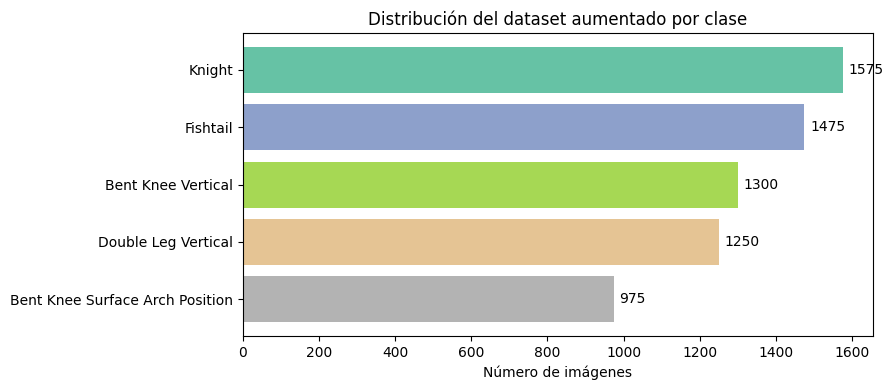

In [5]:
# Visualización de la distribución de clases
conteos  = df['label'].value_counts()
colores  = plt.cm.Set2(np.linspace(0, 1, len(conteos)))

fig, ax = plt.subplots(figsize=(9, 4))
barras  = ax.barh(conteos.index, conteos.values, color=colores)
ax.bar_label(barras, padding=4, fontsize=10)
ax.set_xlabel('Número de imágenes')
ax.set_title('Distribución del dataset aumentado por clase')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

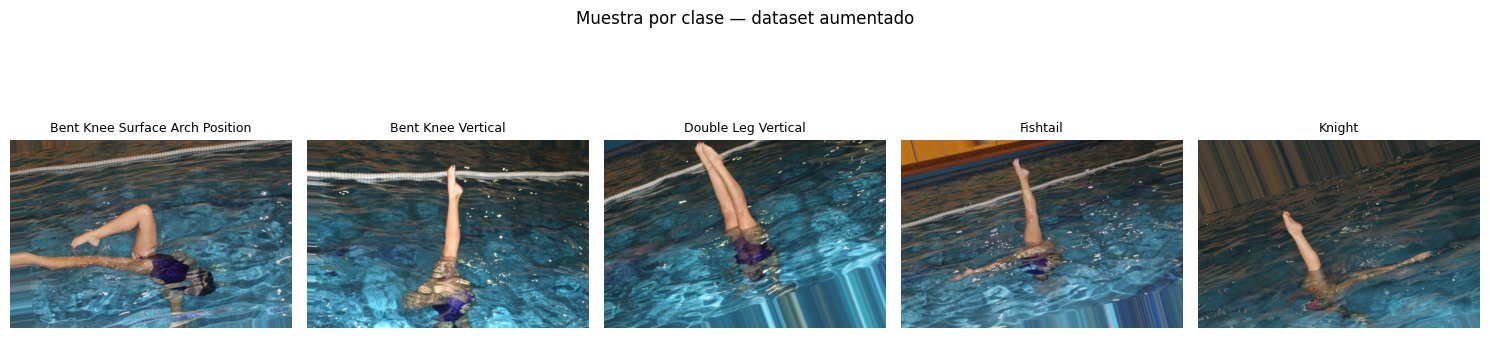

In [6]:
# Una imagen de muestra por clase
CLASES = sorted(df['label'].unique())

fig, axes = plt.subplots(1, len(CLASES), figsize=(15, 4))
for ax, cls in zip(axes, CLASES):
    muestra = df[df['label'] == cls].sample(1, random_state=SEED).iloc[0]
    img     = Image.open(muestra['abs_path']).convert('RGB')
    ax.imshow(img)
    ax.set_title(cls, fontsize=9)
    ax.axis('off')
plt.suptitle('Muestra por clase — dataset aumentado', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

---
## 3. División del dataset

Se realiza una partición estratificada por clase: **70 % entrenamiento · 15 % validación · 15 % test**.

In [7]:
# Codificación numérica de las etiquetas
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

# Primera división: train+val vs test
df_trainval, df_test = train_test_split(
    df,
    test_size=TEST_RATIO,
    stratify=df['label_enc'],
    random_state=SEED,
)

# Segunda división: train vs val
df_train, df_val = train_test_split(
    df_trainval,
    test_size=VAL_RATIO / (1.0 - TEST_RATIO),
    stratify=df_trainval['label_enc'],
    random_state=SEED,
)

for nombre, subdf in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    print(f'{nombre:>5}: {len(subdf):>5} imágenes')
    dist = subdf['label'].value_counts()
    for cls, n in dist.items():
        print(f'         {cls}: {n}')
    print()

Train:  4601 imágenes
         Knight: 1102
         Fishtail: 1032
         Bent Knee Vertical: 910
         Double Leg Vertical: 874
         Bent Knee Surface Arch Position: 683

  Val:   987 imágenes
         Knight: 236
         Fishtail: 222
         Bent Knee Vertical: 195
         Double Leg Vertical: 188
         Bent Knee Surface Arch Position: 146

 Test:   987 imágenes
         Knight: 237
         Fishtail: 221
         Bent Knee Vertical: 195
         Double Leg Vertical: 188
         Bent Knee Surface Arch Position: 146



---
## 4. Dataset personalizado y DataLoaders

La tarea se formula como *Visual Question Answering*:
- **Entrada** (entrenamiento): imagen + `"Question: … Answer: [CLASE]"`
- **Entrada** (inferencia): imagen + `"Question: … Answer:"`
- **Etiqueta de pérdida**: tokens de la clase objetivo (los tokens de la pregunta se enmascaran con `-100`)

In [8]:
class NatacionVQADataset(Dataset):
    """
    Dataset de natación artística formateado como tarea VQA para BLIP-2.

    En modo 'train' el texto de entrada incluye la respuesta (clase) tras el
    prompt. Las etiquetas de pérdida enmascaran la parte del prompt para que
    el modelo solo se supervise en la generación de la clase.

    En modo 'eval' el texto de entrada es solo el prompt; la generación libre
    se compara con la etiqueta real para calcular la exactitud.

    Args:
        df:         DataFrame con columnas 'abs_path' y 'label'.
        processor:  Procesador BLIP-2.
        prompt:     Pregunta en inglés a anteponer a la imagen.
        max_length: Longitud máxima de tokenización.
        mode:       'train' o 'eval'.
    """

    def __init__(
        self,
        df: pd.DataFrame,
        processor,
        prompt: str = PROMPT,
        max_length: int = MAX_TEXT_LEN,
        mode: str = 'train',
    ) -> None:
        self.df         = df.reset_index(drop=True)
        self.processor  = processor
        self.prompt     = prompt
        self.max_length = max_length
        self.mode       = mode

        # Longitud del prompt (para enmascarar en los labels de entrenamiento)
        prompt_ids      = processor.tokenizer(prompt, return_tensors='pt').input_ids
        self.prompt_len = prompt_ids.shape[-1]

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> dict:
        fila  = self.df.iloc[idx]
        imagen = Image.open(fila['abs_path']).convert('RGB')
        label  = fila['label']

        # El texto de entrada varía según el modo
        texto = f'{self.prompt} {label}' if self.mode == 'train' else self.prompt

        encoding = self.processor(
            images=imagen,
            text=texto,
            return_tensors='pt',
            padding='max_length',
            max_length=self.max_length,
            truncation=True,
        )

        item = {
            'pixel_values':   encoding['pixel_values'].squeeze(0),
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label_text':     label,
        }

        if self.mode == 'train':
            labels = encoding['input_ids'].clone()
            # Enmascarar tokens del prompt: no se supervisan
            labels[0, :self.prompt_len] = -100
            # Enmascarar tokens de padding
            pad_id = self.processor.tokenizer.pad_token_id
            if pad_id is not None:
                labels[labels == pad_id] = -100
            item['labels'] = labels.squeeze(0)

        return item

In [9]:
# Carga del procesador BLIP-2 (tokenizador + preprocesado de imagen)
print(f'Cargando procesador: {MODEL_ID} ...')
processor = Blip2Processor.from_pretrained(MODEL_ID)
print('Procesador listo.\n')


def collate_fn(batch: list) -> dict:
    """Agrupa una lista de muestras en un batch, apilando tensores."""
    label_texts = [b.pop('label_text') for b in batch]
    collated    = {k: torch.stack([b[k] for b in batch]) for k in batch[0]}
    collated['label_text'] = label_texts
    return collated


# DataLoaders para cada partición
ds_train = NatacionVQADataset(df_train, processor, mode='train')
ds_val   = NatacionVQADataset(df_val,   processor, mode='eval')
ds_test  = NatacionVQADataset(df_test,  processor, mode='eval')

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, collate_fn=collate_fn)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_fn)
dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_fn)

print(f'Batches — Train: {len(dl_train)} · Val: {len(dl_val)} · Test: {len(dl_test)}')

Cargando procesador: Salesforce/blip2-opt-2.7b ...


The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Procesador listo.

Batches — Train: 1151 · Val: 247 · Test: 247


---
## 5. Configuración del modelo: BLIP-2 + LoRA

### ¿Por qué LoRA?

BLIP-2 tiene ~3.4 B de parámetros. Actualizar todos ellos requeriría decenas de GB de VRAM y horas de cómputo en GPU de consumo. **LoRA** (*Low-Rank Adaptation*) resuelve esto descomponiendo el update de cada capa de atención como el producto de dos matrices de bajo rango:

$$W' = W + \Delta W = W + B \cdot A \quad (r \ll d)$$

Con rango `r=16`, solo se entrenan ~8 M de parámetros (~0.24 % del total).

In [10]:
print(f'Cargando modelo base: {MODEL_ID}\n(esto puede tardar varios minutos la primera vez)\n')

# Cuantización en 8 bits si hay GPU disponible (reduce VRAM ~50 %)
USE_8BIT = torch.cuda.is_available()

if USE_8BIT:
    bnb_config = BitsAndBytesConfig(load_in_8bit=True)
    model = Blip2ForConditionalGeneration.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map='auto',
    )
    # Preparar el modelo cuantizado para fine-tuning (activa gradient checkpointing, etc.)
    model = prepare_model_for_kbit_training(model)
else:
    # Fallback a CPU con precisión completa (solo para pruebas; muy lento)
    model = Blip2ForConditionalGeneration.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float32,
    )
    model = model.to(DEVICE)

print('Modelo base cargado.\n')

# ── Configuración LoRA ────────────────────────────────────────────────────────
# Se adaptan las proyecciones Query y Value del decodificador de lenguaje (OPT)
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias='none',
    task_type=TaskType.CAUSAL_LM,
    target_modules=['q_proj', 'v_proj'],
)

model = get_peft_model(model, lora_config)

# Resumen de parámetros
params_total       = sum(p.numel() for p in model.parameters())
params_entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros totales:       {params_total:>12,}')
print(f'Parámetros entrenables:   {params_entrenables:>12,}  ({100 * params_entrenables / params_total:.2f} %)')

Cargando modelo base: Salesforce/blip2-opt-2.7b
(esto puede tardar varios minutos la primera vez)



Loading weights: 100%|██████████| 1247/1247 [00:03<00:00, 343.83it/s, Materializing param=vision_model.post_layernorm.weight]                               


Modelo base cargado.

Parámetros totales:       3,750,004,736
Parámetros entrenables:      5,242,880  (0.14 %)


---
## 6. Entrenamiento (fine-tuning supervisado)

In [11]:
def normalizar_prediccion(pred: str, clases: list[str]) -> str:
    """
    Mapea la respuesta generada en texto libre al nombre de clase más cercano.
    Primero intenta coincidencia exacta (insensible a mayúsculas); si no
    encuentra ninguna, selecciona la clase que comparte más palabras con la
    predicción.

    Args:
        pred:   Texto generado por el modelo.
        clases: Lista de nombres de clase válidos.

    Returns:
        El nombre de clase normalizado.
    """
    pred_norm = pred.strip().lower()

    # 1. Coincidencia exacta
    for cls in clases:
        if cls.lower() == pred_norm:
            return cls

    # 2. Coincidencia de subcadena
    for cls in clases:
        if cls.lower() in pred_norm or pred_norm in cls.lower():
            return cls

    # 3. Máximo de palabras compartidas
    mejor_cls, mejor_n = clases[0], 0
    for cls in clases:
        n_comunes = sum(w in pred_norm for w in cls.lower().split())
        if n_comunes > mejor_n:
            mejor_n, mejor_cls = n_comunes, cls
    return mejor_cls


def entrenar_epoca(
    model,
    dataloader: DataLoader,
    optimizer,
    device: torch.device,
) -> float:
    """
    Realiza una época de entrenamiento.

    Args:
        model:      Modelo BLIP-2 con adaptadores LoRA.
        dataloader: DataLoader del conjunto de entrenamiento.
        optimizer:  Optimizador (AdamW).
        device:     Dispositivo de cómputo.

    Returns:
        Pérdida media de la época.
    """
    model.train()
    total_loss = 0.0

    for batch in tqdm(dataloader, desc='  Entrenando', leave=False):
        _ = batch.pop('label_text')          # No se usa en el forward de entrenamiento
        pixel_values   = batch['pixel_values'].to(device)
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )

        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


@torch.no_grad()
def evaluar(
    model,
    dataloader: DataLoader,
    device: torch.device,
    clases: list[str],
    desc: str = 'Evaluando',
) -> tuple[float, list[str], list[str]]:
    """
    Evalúa el modelo mediante generación libre de texto.

    Args:
        model:      Modelo a evaluar.
        dataloader: DataLoader del conjunto de evaluación.
        device:     Dispositivo de cómputo.
        clases:     Lista de nombres de clase válidos.
        desc:       Descripción para la barra de progreso.

    Returns:
        Tupla (accuracy, y_true, y_pred_normalizado).
    """
    model.eval()
    y_true, y_pred = [], []

    for batch in tqdm(dataloader, desc=f'  {desc}', leave=False):
        label_texts    = batch.pop('label_text')
        pixel_values   = batch['pixel_values'].to(device)
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        generated = model.generate(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=MAX_NEW_TOKENS,
        )

        predicciones = processor.batch_decode(generated, skip_special_tokens=True)

        y_true.extend(label_texts)
        y_pred.extend([normalizar_prediccion(p, clases) for p in predicciones])

    acc = accuracy_score(y_true, y_pred)
    return acc, y_true, y_pred

In [22]:
# ── Subconjunto de prueba rápida (10 imágenes por clase = 50 en total) ────────
# pd.concat con iteración explícita evita que groupby() elimine la columna
# 'label' del resultado (comportamiento de pandas >= 2.2).
N_POR_CLASE_MINI = 10

df_train_mini = pd.concat([
    df_train.loc[df_train['label'] == cls, ['filepath', 'label', 'abs_path']]
    .sample(min(N_POR_CLASE_MINI, int((df_train['label'] == cls).sum())), random_state=SEED)
    for cls in CLASES
]).reset_index(drop=True)

ds_train_mini = NatacionVQADataset(df_train_mini, processor, mode='train')
dl_train_mini = DataLoader(
    ds_train_mini, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, collate_fn=collate_fn,
)

print(f'Subconjunto de prueba: {len(df_train_mini)} imágenes · {len(dl_train_mini)} batches')
print('Distribución:')
print(df_train_mini['label'].value_counts().to_string())
print()

# ── Optimizador y scheduler ───────────────────────────────────────────────────
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=0.01,
)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# ── Bucle de entrenamiento ────────────────────────────────────────────────────
MODEL_SAVE.mkdir(parents=True, exist_ok=True)
ruta_mejor = MODEL_SAVE / 'mejor_checkpoint'

historial = {'train_loss': [], 'val_acc': []}
mejor_val_acc = 0.0

print(f'Inicio del fine-tuning · {NUM_EPOCHS} épocas · {DEVICE}')
print(f'Train: {len(df_train_mini)} imágenes (mini)  ·  Val: {len(df_val)} imágenes (completo)\n')
print(f'{"Época":>5} | {"Train Loss":>10} | {"Val Acc":>8}')
print('-' * 32)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss = entrenar_epoca(model, dl_train_mini, optimizer, DEVICE)
    val_acc, _, _ = evaluar(model, dl_val, DEVICE, CLASES, desc='Validando')

    historial['train_loss'].append(tr_loss)
    historial['val_acc'].append(val_acc)

    scheduler.step()

    marca = '← mejor' if val_acc > mejor_val_acc else ''
    print(f'{epoch:>5} | {tr_loss:>10.4f} | {val_acc:>8.4f}  {marca}')

    if val_acc > mejor_val_acc:
        mejor_val_acc = val_acc
        model.save_pretrained(str(ruta_mejor))

print(f'\nFine-tuning completado. Mejor val_acc: {mejor_val_acc:.4f}')
print('(Para entrenar sobre el dataset completo sustituir dl_train_mini por dl_train)')

Subconjunto de prueba: 50 imágenes · 13 batches
Distribución:
label
Bent Knee Surface Arch Position    10
Bent Knee Vertical                 10
Double Leg Vertical                10
Fishtail                           10
Knight                             10

Inicio del fine-tuning · 5 épocas · cpu
Train: 50 imágenes (mini)  ·  Val: 987 imágenes (completo)

Época | Train Loss |  Val Acc
--------------------------------


KeyboardInterrupt: 

In [ ]:
# # Optimizador y scheduler de tasa de aprendizaje
# optimizer = AdamW(
#     filter(lambda p: p.requires_grad, model.parameters()),
#     lr=LR,
#     weight_decay=0.01,
# )
# scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# # Preparar directorio de guardado
# MODEL_SAVE.mkdir(parents=True, exist_ok=True)
# ruta_mejor = MODEL_SAVE / 'mejor_checkpoint'

# historial = {'train_loss': [], 'val_acc': []}
# mejor_val_acc = 0.0

# print(f'Inicio del fine-tuning · {NUM_EPOCHS} épocas · {DEVICE}\n')
# print(f'{"Época":>5} | {"Train Loss":>10} | {"Val Acc":>8}')
# print('-' * 32)

# for epoch in range(1, NUM_EPOCHS + 1):
#     tr_loss = entrenar_epoca(model, dl_train, optimizer, DEVICE)
#     val_acc, _, _ = evaluar(model, dl_val, DEVICE, CLASES, desc='Validando')

#     historial['train_loss'].append(tr_loss)
#     historial['val_acc'].append(val_acc)

#     scheduler.step()

#     marca = '← mejor' if val_acc > mejor_val_acc else ''
#     print(f'{epoch:>5} | {tr_loss:>10.4f} | {val_acc:>8.4f}  {marca}')

#     if val_acc > mejor_val_acc:
#         mejor_val_acc = val_acc
#         model.save_pretrained(str(ruta_mejor))

# print(f'\nFine-tuning completado. Mejor val_acc: {mejor_val_acc:.4f}')

Inicio del fine-tuning · 5 épocas · cpu

Época | Train Loss |  Val Acc
--------------------------------


KeyboardInterrupt: 

In [ ]:
# Curvas de entrenamiento
epocas = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(epocas, historial['train_loss'], marker='o', color='steelblue')
ax1.set_title('Pérdida de entrenamiento por época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss (cross-entropy)')
ax1.grid(True, alpha=0.3)

ax2.plot(epocas, historial['val_acc'], marker='s', color='darkorange')
ax2.set_title('Exactitud de validación por época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

plt.suptitle('Curvas de entrenamiento — BLIP-2 + LoRA', fontsize=13)
plt.tight_layout()
plt.savefig(MODEL_SAVE / 'curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Evaluación sobre el conjunto de test

In [ ]:
print('Evaluando sobre el conjunto de test con el mejor checkpoint...\n')
test_acc, y_true, y_pred = evaluar(model, dl_test, DEVICE, CLASES, desc='Test')
print(f'Test Accuracy: {test_acc:.4f}  ({test_acc * 100:.2f} %)')

In [ ]:
# Etiquetas abreviadas para los gráficos
ABREV = {
    'Double Leg Vertical':               'DLV',
    'Fishtail':                          'Fishtail',
    'Bent Knee Vertical':                'BKV',
    'Bent Knee Surface Arch Position':   'BKSA',
    'Knight':                            'Knight',
}

# Matriz de confusión
cm            = confusion_matrix(y_true, y_pred, labels=CLASES)
display_labels = [ABREV.get(c, c) for c in CLASES]

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=30)
ax.set_title('Matriz de confusión — BLIP-2 fine-tuned (Test)')
plt.tight_layout()
plt.savefig(MODEL_SAVE / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Informe de clasificación detallado
print('Informe de clasificación (Test):\n')
print(
    classification_report(
        y_true,
        y_pred,
        labels=CLASES,
        target_names=display_labels,
        digits=4,
    )
)

---
## 8. Predicciones de muestra

Se muestran ejemplos del conjunto de test con la predicción generada. El borde **verde** indica acierto y el **rojo** indica error.

In [ ]:
@torch.no_grad()
def mostrar_predicciones(
    df_split: pd.DataFrame,
    model,
    processor,
    device: torch.device,
    clases: list[str],
    n_por_clase: int = 2,
    seed: int = SEED,
) -> None:
    """
    Muestra una cuadrícula de imágenes con las predicciones del modelo.
    Cada columna corresponde a una clase; borde verde = correcto, rojo = error.

    Args:
        df_split:    DataFrame de la partición a visualizar.
        model:       Modelo fine-tuned.
        processor:   Procesador BLIP-2.
        device:      Dispositivo de cómputo.
        clases:      Lista de nombres de clase válidos.
        n_por_clase: Número de ejemplos por clase a mostrar.
        seed:        Semilla de muestreo.
    """
    model.eval()
    muestras = (
        df_split
        .groupby('label', group_keys=False)
        .apply(lambda g: g.sample(min(n_por_clase, len(g)), random_state=seed))
        .reset_index(drop=True)
    )

    fig, axes = plt.subplots(
        n_por_clase, len(clases),
        figsize=(3.5 * len(clases), 4 * n_por_clase),
    )
    if n_por_clase == 1:
        axes = axes.reshape(1, -1)

    for col, cls in enumerate(clases):
        filas_cls = muestras[muestras['label'] == cls].reset_index(drop=True)
        for row in range(n_por_clase):
            ax  = axes[row, col]
            if row >= len(filas_cls):
                ax.axis('off')
                continue
            fila = filas_cls.iloc[row]
            img  = Image.open(fila['abs_path']).convert('RGB')

            enc = processor(
                images=img,
                text=PROMPT,
                return_tensors='pt',
                padding='max_length',
                max_length=MAX_TEXT_LEN,
                truncation=True,
            ).to(device)

            gen  = model.generate(
                pixel_values=enc['pixel_values'],
                input_ids=enc['input_ids'],
                attention_mask=enc['attention_mask'],
                max_new_tokens=MAX_NEW_TOKENS,
            )
            pred_raw = processor.decode(gen[0], skip_special_tokens=True).strip()
            pred     = normalizar_prediccion(pred_raw, clases)

            correcto     = pred == cls
            color_borde  = 'green' if correcto else 'red'

            ax.imshow(img)
            ax.axis('off')
            titulo = f'Real: {ABREV.get(cls, cls)}\nPred: {ABREV.get(pred, pred)}'
            ax.set_title(titulo, fontsize=9, color=color_borde)
            for spine in ax.spines.values():
                spine.set_edgecolor(color_borde)
                spine.set_linewidth(3)

    verde = mpatches.Patch(color='green', label='Correcto')
    rojo  = mpatches.Patch(color='red',   label='Incorrecto')
    fig.legend(handles=[verde, rojo], loc='lower right', fontsize=11)
    plt.suptitle('Predicciones de muestra — BLIP-2 fine-tuned (Test)', fontsize=13)
    plt.tight_layout()
    plt.savefig(MODEL_SAVE / 'predicciones_muestra.png', dpi=150, bbox_inches='tight')
    plt.show()


mostrar_predicciones(df_test, model, processor, DEVICE, CLASES, n_por_clase=2)

---
## 9. Guardado del modelo fine-tuned

Se guardan únicamente los **pesos del adaptador LoRA** (unos pocos MB), junto con el procesador. Para inferencia posterior solo se necesita cargar el modelo base desde HuggingFace Hub y fusionar el adaptador.

In [ ]:
ruta_final = MODEL_SAVE / 'adaptador_lora_final'
model.save_pretrained(str(ruta_final))
processor.save_pretrained(str(ruta_final))

print(f'Adaptador LoRA guardado en: {ruta_final.resolve()}')
print()
print('Para cargar el modelo fine-tuned en una sesión posterior:')
print(f"""
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from peft import PeftModel

base  = Blip2ForConditionalGeneration.from_pretrained('{MODEL_ID}')
model = PeftModel.from_pretrained(base, '{ruta_final}')
proc  = Blip2Processor.from_pretrained('{ruta_final}')
""")